# Análisis del dataset de detección SMishing

## 1. Carga y configuración

In [22]:
from google.colab import drive
drive.mount('/content/drive')
DATASET_PATH = '/content/drive/MyDrive/TFG_Posdata/scripts/datasets/dataset_final.csv'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from collections import Counter
import re
import warnings
warnings.filterwarnings('ignore')

SPAM_COLOR = '#E24B4A'
HAM_COLOR = '#1D9E75'
BLUE_COLOR = '#378ADD'
GRAY_COLOR = '#888780'
BG_COLOR = '#FAFAF8'
GRID_COLOR = '#E8E6E0'

plt.rcParams.update({
    'figure.facecolor':BG_COLOR,
    'axes.facecolor':BG_COLOR,
    'axes.grid':True,
    'grid.color':GRID_COLOR,
    'grid.linewidth':0.6,
    'axes.spines.top':False,
    'axes.spines.right':False,
    'font.family':'DejaVu Sans',
    'axes.titlesize':13,
    'axes.titleweight':'bold',
    'axes.labelsize':11,
    'xtick.labelsize':10,
    'ytick.labelsize':10,
})

df = pd.read_csv(DATASET_PATH)

print(f'Filas: {len(df):,}')
print(f'Columnas: {df.columns.tolist()}')

Filas: 5,754
Columnas: ['label', 'text', 'lang', 'source']


In [24]:
spam = df[df['label'] == 'spam']
ham  = df[df['label'] == 'ham']

print(f'Spam: {len(spam):,}  |  Ham: {len(ham):,}  |  Ratio: {len(ham)/len(spam):.1f}:1')

Spam: 988  |  Ham: 4,766  |  Ratio: 4.8:1


## 2. Distribución del dataset

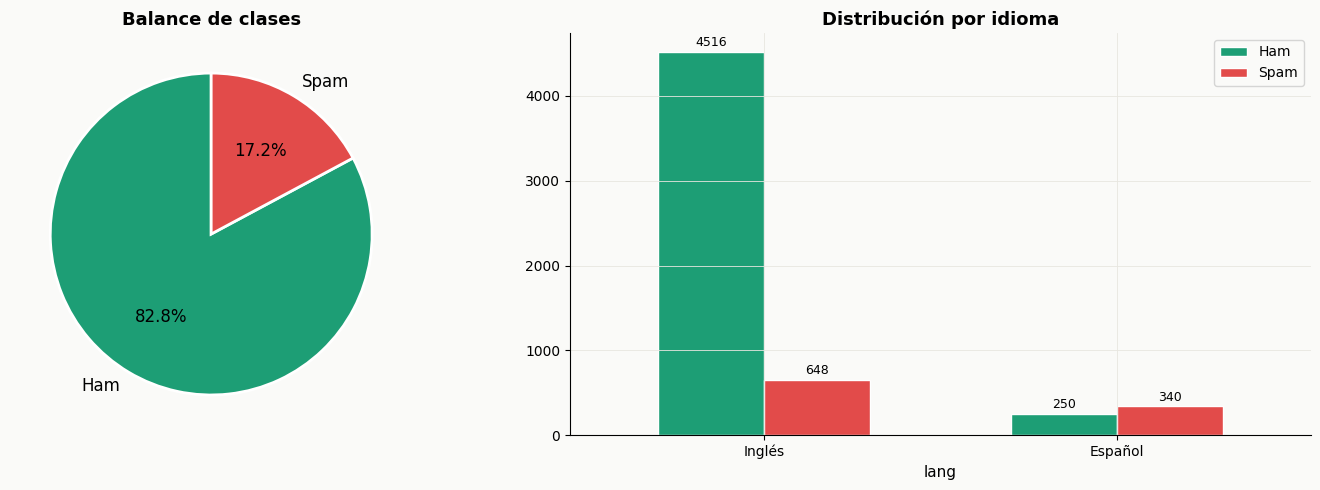

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

counts = df['label'].value_counts()
axes[0].pie(counts, labels=['Ham', 'Spam'], colors=[HAM_COLOR, SPAM_COLOR],
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2},
            textprops={'fontsize': 12})
axes[0].set_title('Balance de clases')

lang_label = df.groupby(['lang', 'label']).size().unstack()
lang_label.plot(kind='bar', ax=axes[1], color=[HAM_COLOR, SPAM_COLOR], edgecolor='white', width=0.6)
axes[1].set_title('Distribución por idioma')
axes[1].set_xticklabels(['Inglés', 'Español'], rotation=0)
axes[1].legend(['Ham', 'Spam'])
for c in axes[1].containers:
    axes[1].bar_label(c, fontsize=9, padding=2)

plt.tight_layout()
plt.show()

## 3. Top palabras más usadas

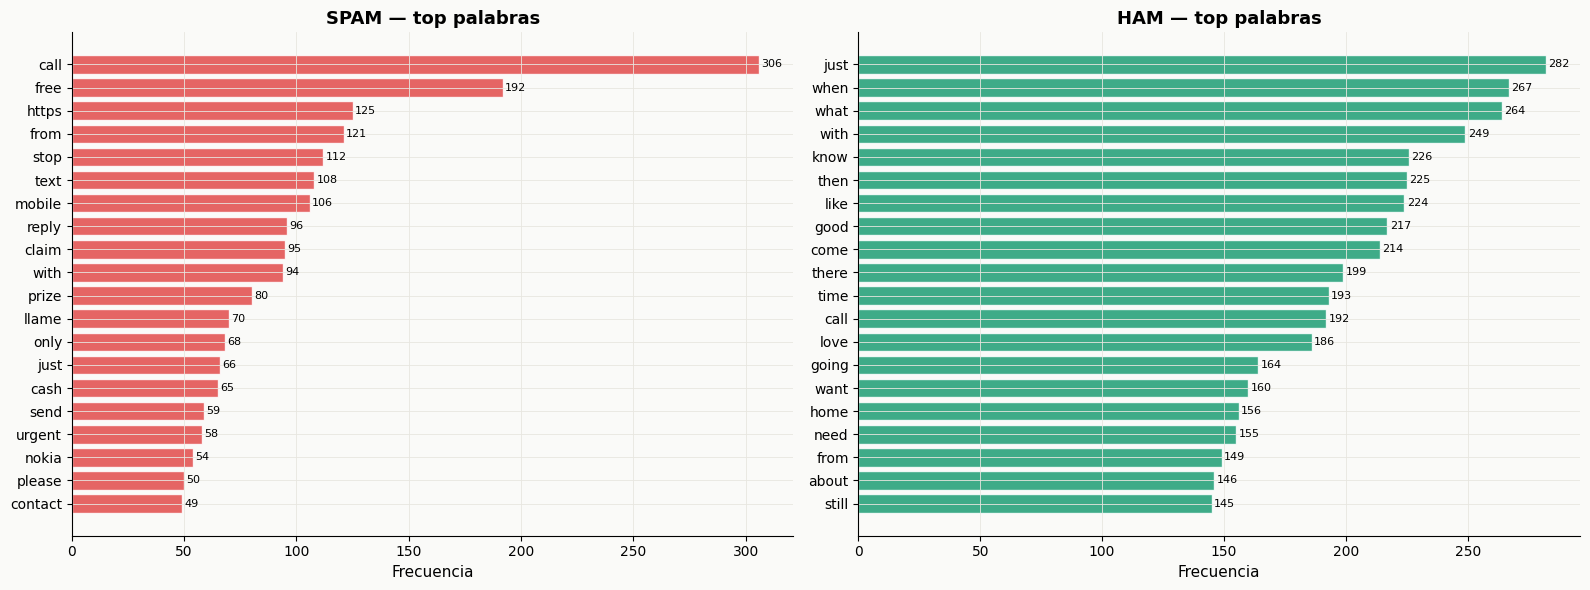

In [26]:
stopwords = {
    'de','la','el','en','su','que','por','para','no','se','ha','le','con','un','una',
    'es','al','los','las','del','si','lo','tu','sus','nos','más','pero','como','sin',
    'será','está','fue','han','ser','puede','hay','the','a','an','to','is','in','of',
    'and','you','your','for','my','me','it','i','we','our','this','that','or','at',
    'be','on','do','not','are','have','will','its','by','has','he','she','they','was'
}

def top_words(texts, n=20):
    words = []
    for t in texts:
        for w in re.findall(r'\b[a-záéíóúüñA-ZÁÉÍÓÚÜÑ]{4,}\b', str(t).lower()):
            if w not in stopwords:
                words.append(w)
    return Counter(words).most_common(n)

spam_words = top_words(spam['text'])
ham_words  = top_words(ham['text'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, words, color, title in [
    (axes[0], spam_words, SPAM_COLOR, 'SPAM — top palabras'),
    (axes[1], ham_words,  HAM_COLOR,  'HAM — top palabras'),
]:
    labels = [w for w, _ in words][::-1]
    vals   = [c for _, c in words][::-1]
    bars   = ax.barh(labels, vals, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(title)
    ax.set_xlabel('Frecuencia')
    for b in bars:
        ax.text(b.get_width()+1, b.get_y()+b.get_height()/2,
                str(int(b.get_width())), va='center', fontsize=8)

plt.tight_layout()
plt.show()